# 04 – Confidence Intervals & Hypothesis Tests

Author: Joe  
Project: AI Foundations – Probability & Statistics

This notebook introduces **statistical inference**:

- using sample data to say something about an unknown population parameter,
- quantifying uncertainty via **confidence intervals**, and
- making decisions with **hypothesis tests**.

We'll focus on simple but very common cases:

- Confidence intervals for a **proportion** and a **mean**
- One-sample **z-tests** for a proportion and for a mean
- How p-values, significance level, and Type I/II errors fit together.


## Contents
1. [Setup](#1-setup)
2. [Sampling and Sample Statistics](#2-sampling-and-sample-statistics)
3. [Confidence Intervals for a Proportion](#3-confidence-intervals-for-a-proportion)
4. [Confidence Intervals for a Mean](#4-confidence-intervals-for-a-mean)
5. [Hypothesis Testing Basics](#5-hypothesis-testing-basics)
6. [One-sample z-test for a Proportion](#6-one-sample-z-test-for-a-proportion)
7. [One-sample z-test for a Mean](#7-one-sample-z-test-for-a-mean)
8. [Practice / TODOs](#8-practice--todos)


## 1. Setup

In [10]:
import math
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

np.set_printoptions(precision=4, suppress=True)

def normal_cdf(z: float) -> float:
    """Standard normal CDF using the error function."""
    return 0.5 * (1 + math.erf(z / math.sqrt(2)))

def z_critical(conf_level: float) -> float:
    """Return a common z critical value for two-sided intervals.

    Supports a few standard confidence levels.
    """
    if abs(conf_level - 0.90) < 1e-8:
        return 1.645
    if abs(conf_level - 0.95) < 1e-8:
        return 1.96
    if abs(conf_level - 0.99) < 1e-8:
        return 2.576
    # Fallback: approximate with inverse CDF via binary search
    alpha = 1 - conf_level
    target = 1 - alpha / 2
    lo, hi = 0.0, 5.0
    for _ in range(60):
        mid = 0.5 * (lo + hi)
        if normal_cdf(mid) < target:
            lo = mid
        else:
            hi = mid
    return 0.5 * (lo + hi)


---
## 2. Sampling and Sample Statistics

In inference we imagine there is a **population** with some true parameter:

- Population mean $\mu$ (for quantitative data)
- Population proportion $p$ (for success/failure data)

We don't know $\mu$ or $p$, but we take a **sample** of size $n$ and compute:

- Sample mean $\bar{X}$ as an estimate of $\mu$
- Sample proportion $\hat{p}$ as an estimate of $p$

The key idea is that if we repeated the sampling process many times, these estimates would vary.
Confidence intervals and hypothesis tests describe that variability in a structured way.

In [11]:
# Example: sampling from a Normal population and looking at sample means
mu_true = 10.0
sigma_true = 3.0
n = 30
n_samples = 5000

sample_means = []
for _ in range(n_samples):
    sample = np.random.normal(loc=mu_true, scale=sigma_true, size=n)
    sample_means.append(sample.mean())

sample_means = np.array(sample_means)

sample_means.mean(), sample_means.var(ddof=1)

(np.float64(10.011968472340529), np.float64(0.3023830473783274))

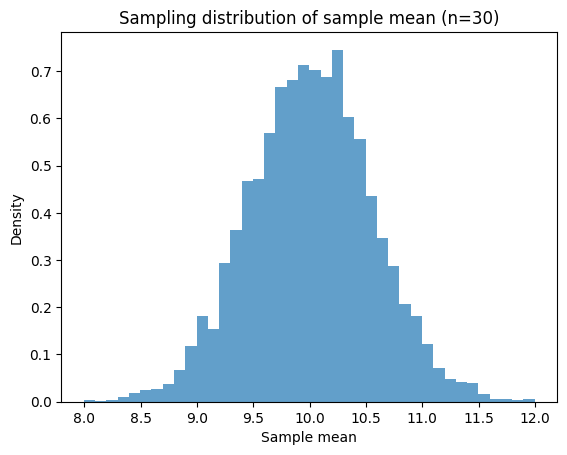

In [12]:
# Visualise the sampling distribution of the sample mean
plt.hist(sample_means, bins=40, density=True, alpha=0.7)
plt.xlabel('Sample mean')
plt.ylabel('Density')
plt.title('Sampling distribution of sample mean (n=30)')
plt.show()

---
## 3. Confidence Intervals for a Proportion

Suppose we observe $X$ successes out of $n$ independent trials, each with probability $p$ of success.
We estimate $p$ with the sample proportion
$$\hat{p} = \frac{X}{n}.$$

For reasonably large $n$ (and not-too-extreme $p$), the sampling distribution of $\hat{p}$ is
approximately Normal:
$$\hat{p} \approx \mathcal{N}\left(p, \frac{p(1-p)}{n}\right).$$

A **(1-\alpha)100\% confidence interval** for $p$ is then
$$\hat{p} \pm z_{\alpha/2} \sqrt{\frac{\hat{p}(1-\hat{p})}{n}},$$
where $z_{\alpha/2}$ is the appropriate critical value from the standard Normal distribution.

Typical choices:
- 90% CI: $z \approx 1.645$
- 95% CI: $z \approx 1.96$
- 99% CI: $z \approx 2.576$


In [13]:
def ci_proportion(x: int, n: int, conf_level: float = 0.95):
    """Wald confidence interval for a proportion.

    x: number of successes
    n: sample size
    conf_level: e.g. 0.95 for 95% CI
    """
    p_hat = x / n
    z = z_critical(conf_level)
    se = math.sqrt(p_hat * (1 - p_hat) / n)
    lower = p_hat - z * se
    upper = p_hat + z * se
    return p_hat, lower, upper

# Example: 56 successes out of 100 trials
p_hat, lower, upper = ci_proportion(56, 100, conf_level=0.95)
p_hat, lower, upper

(0.56, 0.46270815861543174, 0.6572918413845683)

In [14]:
# Coverage illustration: how often does a 95% CI contain the true p?
p_true = 0.6
n = 100
conf_level = 0.95
n_experiments = 2000

contains = 0
lengths = []

for _ in range(n_experiments):
    x = np.random.binomial(n=n, p=p_true)
    p_hat, lower, upper = ci_proportion(x, n, conf_level=conf_level)
    if lower <= p_true <= upper:
        contains += 1
    lengths.append(upper - lower)

coverage_rate = contains / n_experiments
avg_length = float(np.mean(lengths))
coverage_rate, avg_length

(0.9535, 0.19102781094336393)

---
## 4. Confidence Intervals for a Mean

Let $X_1, \dots, X_n$ be i.i.d. with population mean $\mu$ and variance $\sigma^2$.
The sample mean $\bar{X}$ is an estimator of $\mu$.

### 4.1 Known variance (z-interval)

If we know the population standard deviation $\sigma$, then for large $n$ (or Normal data),
$$\bar{X} \sim \mathcal{N}\left(\mu, \frac{\sigma^2}{n}\right).$$

A two-sided $(1-\alpha)100\%$ confidence interval for $\mu$ is
$$\bar{X} \pm z_{\alpha/2} \frac{\sigma}{\sqrt{n}}.$$

### 4.2 Unknown variance (t-interval)

If $\sigma$ is unknown, we estimate it with the sample standard deviation $S$ and use the **t-distribution**:
$$\text{CI}: \bar{X} \pm t_{\alpha/2, n-1} \frac{S}{\sqrt{n}}.$$

In this notebook we implement the **z-interval** case explicitly (good approximation for large $n$),
and note where the t-critical values would appear in your R / calculator workflow.

In [15]:
def ci_mean_known_sigma(sample: np.ndarray, sigma: float, conf_level: float = 0.95):
    """Confidence interval for the mean with known population sigma.

    sample: 1D array of observations
    sigma: known population standard deviation
    conf_level: e.g. 0.95 for 95% CI
    """
    n = len(sample)
    x_bar = float(sample.mean())
    z = z_critical(conf_level)
    se = sigma / math.sqrt(n)
    lower = x_bar - z * se
    upper = x_bar + z * se
    return x_bar, lower, upper

# Example: sample from N(10, 3^2) with known sigma=3
mu_true = 10
sigma_true = 3
np.random.seed(0)
sample = np.random.normal(loc=mu_true, scale=sigma_true, size=40)

x_bar, lower, upper = ci_mean_known_sigma(sample, sigma=sigma_true, conf_level=0.95)
x_bar, lower, upper

(10.937627419648521, 10.007917787559018, 11.867337051738025)

---
## 5. Hypothesis Testing Basics

A **hypothesis test** is a structured way to check whether sample data are compatible with some
claim about the population.

Key ingredients:

- **Null hypothesis** $H_0$: the default claim ("no effect", "no difference").
- **Alternative hypothesis** $H_1$ (or $H_a$): what you suspect might be true instead.
- **Test statistic**: a number computed from the data that measures disagreement with $H_0$.
- **p-value**: probability, assuming $H_0$ is true, of getting a test statistic at least as extreme
  as the one observed.
- **Significance level** $\alpha$: threshold for how much evidence against $H_0$ we require
  (often 0.05).

Decision rule:

- If p-value $\le \alpha$: reject $H_0$ (evidence against $H_0$).
- If p-value $> \alpha$: fail to reject $H_0$ (data are compatible with $H_0$).

Error types:
- **Type I error**: rejecting $H_0$ when it is actually true (false positive). Probability is $\alpha$.
- **Type II error**: failing to reject $H_0$ when $H_1$ is true (false negative).

---
## 6. One-sample z-test for a Proportion

Scenario: we observe $X$ successes out of $n$ trials. We want to test

\begin{align}
H_0 &: p = p_0, \\
H_1 &: p \ne p_0 \quad \text{(two-sided)}.
\end{align}

Test statistic:
$$Z = \frac{\hat{p} - p_0}{\sqrt{\dfrac{p_0 (1-p_0)}{n}}}, \quad \hat{p} = \frac{X}{n}.$$

Under $H_0$, for large $n$, $Z$ is approximately standard Normal.

For a two-sided test, the p-value is
$$p\text{-value} = 2\left(1 - \Phi(|Z|)\right),$$
where $\Phi$ is the standard Normal cdf.

In [16]:
def z_test_proportion(x: int, n: int, p0: float, alternative: str = 'two-sided'):
    """One-sample z-test for a proportion.

    x: number of successes
    n: sample size
    p0: null hypothesised proportion
    alternative: 'two-sided', 'greater', or 'less'
    """
    p_hat = x / n
    se0 = math.sqrt(p0 * (1 - p0) / n)
    z = (p_hat - p0) / se0

    if alternative == 'two-sided':
        p_value = 2 * (1 - normal_cdf(abs(z)))
    elif alternative == 'greater':
        p_value = 1 - normal_cdf(z)
    elif alternative == 'less':
        p_value = normal_cdf(z)
    else:
        raise ValueError("alternative must be 'two-sided', 'greater', or 'less'")

    return p_hat, z, p_value

# Example: 56 successes out of 100, test H0: p = 0.5 vs two-sided alternative
p_hat, z_stat, p_val = z_test_proportion(56, 100, p0=0.5, alternative='two-sided')
p_hat, z_stat, p_val

(0.56, 1.200000000000001, 0.230139340443416)

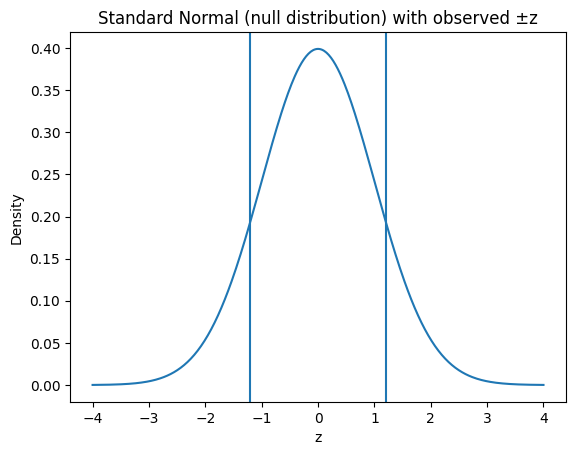

In [17]:
# Visualise the null distribution for the example and observed z
z_vals = np.linspace(-4, 4, 400)
pdf_vals = (1 / math.sqrt(2 * math.pi)) * np.exp(-z_vals ** 2 / 2)

plt.plot(z_vals, pdf_vals)
plt.axvline(z_stat)
plt.axvline(-z_stat)
plt.xlabel('z')
plt.ylabel('Density')
plt.title('Standard Normal (null distribution) with observed ±z')
plt.show()

---
## 7. One-sample z-test for a Mean (Known Variance)

Scenario: we have a sample $X_1, \dots, X_n$ from a population with **known** standard deviation $\sigma$.
We want to test
\begin{align}
H_0 &: \mu = \mu_0, \\
H_1 &: \mu \ne \mu_0.
\end{align}

Test statistic:
$$Z = \frac{\bar{X} - \mu_0}{\sigma / \sqrt{n}}.$$

Under $H_0$ (and Normal data or large $n$), $Z$ is approximately standard Normal.

p-values are computed in the same way as for the proportion test, using the Normal cdf.

In [ ]:
def z_test_mean(sample: np.ndarray, mu0: float, sigma: float, alternative: str = 'two-sided'):
    """One-sample z-test for a mean (known sigma)."""
    n = len(sample)
    x_bar = float(sample.mean())
    se0 = sigma / math.sqrt(n)
    z = (x_bar - mu0) / se0

    if alternative == 'two-sided':
        p_value = 2 * (1 - normal_cdf(abs(z)))
    elif alternative == 'greater':
        p_value = 1 - normal_cdf(z)
    elif alternative == 'less':
        p_value = normal_cdf(z)
    else:
        raise ValueError("alternative must be 'two-sided', 'greater', or 'less'")

    return x_bar, z, p_value

# Example: sample from N(10, 3^2), test H0: mu = 9.5
mu_true = 10
sigma_true = 3
np.random.seed(1)
sample = np.random.normal(loc=mu_true, scale=sigma_true, size=40)

x_bar, z_stat_mean, p_val_mean = z_test_mean(sample, mu0=9.5, sigma=sigma_true, alternative='two-sided')
x_bar, z_stat_mean, p_val_mean

(9.731206076293375, 0.4874252066384847, 0.6259570341429008)

: 

---
## 8. Practice / TODOs

### 8.1 Plug in MATH4002 questions

Use this notebook as a template and drop in actual problems from your tutorial sheets, for example:

- Constructing 95% CIs for a proportion (e.g. defective items, survey responses).
- Constructing 95% CIs for a mean (e.g. waiting times, exam scores).
- Performing one-sample tests and interpreting p-values.

### 8.2 Example template – proportion CI and test

**Markdown cell template:**

Question: In a sample of 200 customers, 130 say they are satisfied. Construct a 95% CI for the
true proportion of satisfied customers and test $H_0: p = 0.6$ vs $H_1: p > 0.6$ at level 0.05.

Solution sketch:
- $\hat{p} = 130/200 = 0.65$.
- CI using the `ci_proportion` function.
- z-test using `z_test_proportion` with `alternative='greater'`.

**Code cell template:**

```python
n = 200
x = 130

# 95% CI for p
p_hat, lower, upper = ci_proportion(x, n, conf_level=0.95)
print('p_hat:', p_hat)
print('95% CI:', (lower, upper))

# One-sided test H0: p = 0.6 vs H1: p > 0.6
p_hat, z_stat, p_val = z_test_proportion(x, n, p0=0.6, alternative='greater')
print('z:', z_stat)
print('p-value:', p_val)
```

Repeat this pattern for mean-based questions using `ci_mean_known_sigma` and `z_test_mean`.

As you fill this notebook with concrete problems, it becomes your personal reference guide
for inference with one sample.